###  **Test 1 page segmentation**
The Kraken toolkit segments one manuscript's page and plots the boundaries of each text line relative to the baseline.

In [1]:
import os
import subprocess
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ["PROJECT_ROOT"]

In [2]:
input_path = os.path.join(PROJECT_ROOT, "data/raw/original_manuscript/reproduction14453_100/15 - f. 010v - 011.jpg")
json_name = os.path.splitext(os.path.basename(input_path))[0] + ".json"
json_path = os.path.join(PROJECT_ROOT, "data/processed/segmented_images", json_name)
os.makedirs(os.path.dirname(json_path), exist_ok=True)

In [3]:
try:
    result = subprocess.run(
    ["kraken", "-i", input_path, json_path, "segment", "-bl"],
    check=True,
    capture_output=True,
    text=True
)
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("Kraken failed with error:\n", e.stderr)

Loading ANN D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\.venv\Lib\site-packages\kraken\blla.mlmodel	âœ“
Segmenting D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\data\raw\original_manuscript\reproduction14453_100\15 - f. 010v - 011.jpg	âœ“



#### **Plotting the manuscript's page with the base line and the bounds**

In [69]:
import matplotlib.pyplot as plt
import json
from PIL import Image, ImageDraw, ImageFont

input_image_path = os.path.join(PROJECT_ROOT,"data/raw/original_manuscript/reproduction14453_100/15 - f. 010v - 011.jpg")
json_path = os.path.join(PROJECT_ROOT, "data/processed/segmented_images/15 - f. 010v - 011.json")
output_path = os.path.join(PROJECT_ROOT, "results/image_segmentation/15 - f. 010v - 011.png")

with open(json_path, "r", encoding="utf-8") as f:
    kraken_data = json.load(f)

img = Image.open(input_image_path).convert("RGB")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("arial.ttf", 20)
except:
    font = ImageFont.load_default()

In [70]:
kraken_data

{'type': 'baselines',
 'imagename': 'D:\\Users\\kju10\\Documents\\LMU-STATISTICS & DATA SCIENCE MASTER\\SS2026\\Thesis\\OCC_HTR\\data\\raw\\original_manuscript\\reproduction14453_100\\15 - f. 010v - 011.jpg',
 'text_direction': 'horizontal-lr',
 'script_detection': False,
 'lines': [{'id': '2b623111-e0b5-4a0a-b055-f5c53b0df868',
   'baseline': [[478, 226], [889, 229]],
   'boundary': [[878, 211],
    [866, 211],
    [855, 211],
    [844, 211],
    [833, 211],
    [822, 211],
    [811, 211],
    [800, 211],
    [789, 210],
    [778, 210],
    [767, 210],
    [756, 210],
    [745, 210],
    [733, 210],
    [722, 210],
    [711, 210],
    [700, 210],
    [689, 210],
    [678, 209],
    [667, 209],
    [656, 209],
    [645, 209],
    [634, 209],
    [623, 209],
    [611, 209],
    [600, 209],
    [589, 209],
    [578, 208],
    [567, 208],
    [556, 208],
    [545, 208],
    [534, 208],
    [523, 208],
    [512, 208],
    [501, 208],
    [490, 208],
    [478, 212],
    [478, 226],
    [477

In [71]:
len(kraken_data["lines"])

202

In [72]:
for i, line in enumerate(kraken_data.get("lines", []), start=1):
    # Baseline (red)
    baseline = line["baseline"]
    draw.line([tuple(baseline[0]), tuple(baseline[1])], fill="red", width=2)

    # Boundary polygon (blue)
    boundary = [tuple(pt) for pt in line.get("boundary", [])]
    if boundary:
        draw.polygon(boundary, outline="blue")

    # ID (green)
    x, y = baseline[0]
    draw.text((x-20, y-20), str(i), fill="green", font=font)

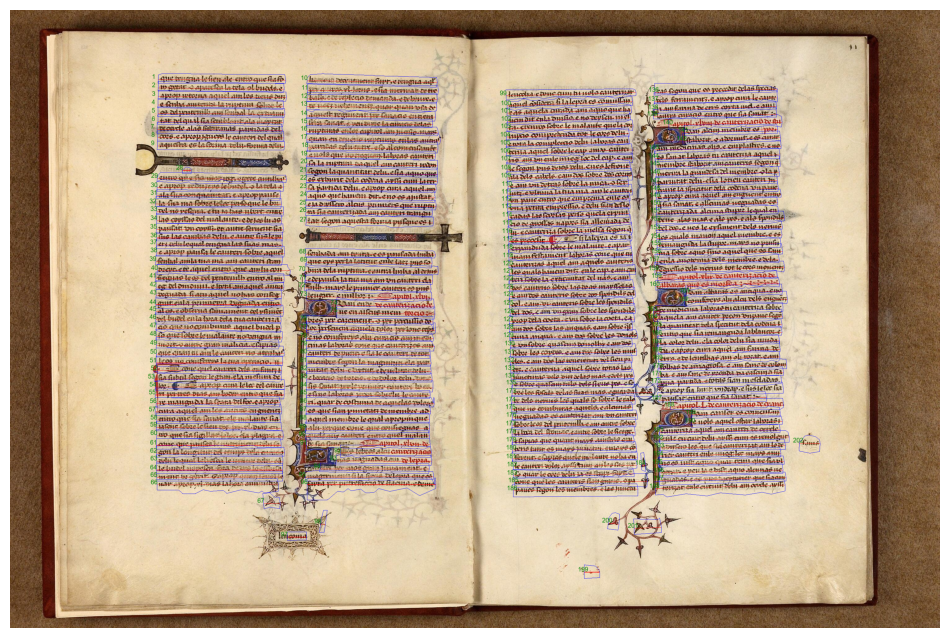

In [73]:
img.save(output_path)
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.show()